<hr><hr>

<h1>Step 1 - <b>Cleaning</b> + <b>Exploratory Data Analysis (EDA)</b> for our <b>MNC Hiring Trends Project</b> (India 2025).</h1>

<h2>🔹 Step 1: <b>Data Cleaning + EDA</b></h2>
<h3>🧩 Objectives</h3>

*   Ensure data is clean and structured for insights.
*   Identify patterns — tech vs. non-tech ratio, hiring trends, salaries, etc.



<hr>

<h2>🧼 1️⃣ <b>Data Cleaning Tasks:</b></h2>

In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"https://raw.githubusercontent.com/aysh01/MNC-Hiring-Trends-Project/refs/heads/main/IT_MNC_Hiring_2025_full.csv")

# Check basic info
print("Shape:", df.shape)
print(df.info())

# Handle missing or invalid data
df = df.dropna(subset=["Company", "Job_Title", "Skills_Required"])
df["CTC(LPA)"] = df["CTC(LPA)"].apply(lambda x: round(x, 1) if x > 0 else None)
df = df.dropna(subset=["CTC(LPA)"])

# Standardize text columns
for col in ["Company", "Location", "Job_Title", "Experience_Level", "Hiring_Type", "Source"]:
    df[col] = df[col].str.strip().str.title()

# Save cleaned dataset
df.to_csv("IT_MNC_Hiring_2025_cleaned.csv", index=False)
print("✅ Data cleaned and saved as 'IT_MNC_Hiring_2025_cleaned.csv'")

Shape: (12000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           12000 non-null  object 
 1   Location          12000 non-null  object 
 2   Job_Title         12000 non-null  object 
 3   Experience_Level  12000 non-null  object 
 4   Skills_Required   12000 non-null  object 
 5   CTC(LPA)          12000 non-null  float64
 6   Hiring_Type       12000 non-null  object 
 7   Source            12000 non-null  object 
 8   Post_Date         12000 non-null  object 
 9   Apply_Link        12000 non-null  object 
dtypes: float64(1), object(9)
memory usage: 937.6+ KB
None
✅ Data cleaned and saved as 'IT_MNC_Hiring_2025_cleaned.csv'


<hr>

<h2>📈 2️⃣ <b>EDA - Key Insights & Ratios</b></h2>

<h4>After cleaning, we’ll explore:</h4>

In [24]:
# 1. Count of jobs by company
print(df["Company"].value_counts())

# 2. Technical vs Non-Technical roles
def classify_role(title, skills):
    non_tech_keywords = ["support", "associate", "process", "voice", "customer"]
    if any(k.lower() in title.lower() or k.lower() in skills.lower() for k in non_tech_keywords):
        return "Non-Technical"
    return "Technical"

df["Role_Type"] = df.apply(lambda x: classify_role(x["Job_Title"], x["Skills_Required"]), axis=1)
print("\n")
print(df["Role_Type"].value_counts(normalize=True) * 100)

# 3. Average salary comparison
print("\n")
print(df.groupby("Role_Type")["CTC(LPA)"].mean())

# 4. Company-wise tech vs non-tech distribution
company_role_ratio = df.groupby(["Company", "Role_Type"]).size().unstack(fill_value=0)
print("\n")
print(company_role_ratio)

Company
Tcs              2337
Infosys          2115
Wipro            1843
Tech Mahindra    1236
Accenture         966
Cognizant         902
Hcl               733
Ibm               697
Ltimindtree       620
Capgemini         551
Name: count, dtype: int64


Role_Type
Technical        62.825
Non-Technical    37.175
Name: proportion, dtype: float64


Role_Type
Non-Technical    11.394149
Technical        11.179109
Name: CTC(LPA), dtype: float64


Role_Type      Non-Technical  Technical
Company                                
Accenture                351        615
Capgemini                203        348
Cognizant                348        554
Hcl                      261        472
Ibm                      258        439
Infosys                  807       1308
Ltimindtree              218        402
Tcs                      870       1467
Tech Mahindra            456        780
Wipro                    689       1154


<hr>

<h2>📊 3️⃣ Ratio of Tech vs Non-Tech Roles</h2>

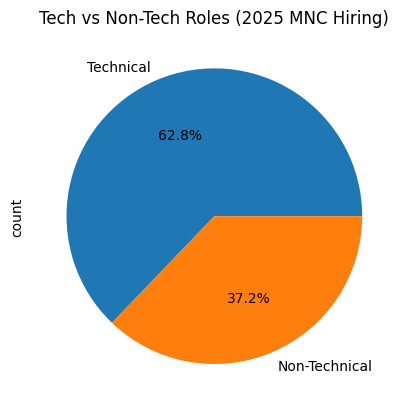

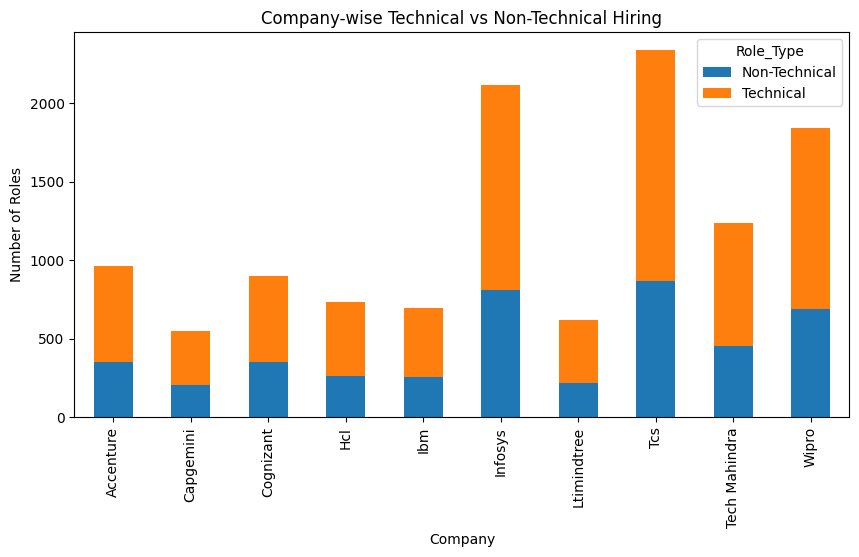

In [26]:
import matplotlib.pyplot as plt

# Pie chart of tech vs non-tech
df["Role_Type"].value_counts().plot(kind="pie", autopct='%1.1f%%', title="Tech vs Non-Tech Roles (2025 MNC Hiring)")
plt.show()

# Company-wise bar chart
company_role_ratio.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Company-wise Technical vs Non-Technical Hiring")
plt.ylabel("Number of Roles")
plt.show()

<hr><hr>

<h2>🚀 Step 2 - <b>Deep Analysis & Insights Dashboard Prep</b></h2>
<h3><b>Advanced analytics</b> to uncover hidden <b>hiring patterns</b> across <b>India’s top MNCs</b>.</h3>

<hr>

<h2>🧭 <b>Step 2 Overview</b></h2>

<h3>We’ll dig into:</h3>

*   <b>Salary Distribution</b> & </b>Gaps (Tech vs Non-Tech).
*   <b>Regional Hiring Patterns</b> (Which <b>city</b> hires most <b>tech talent</b>).
*   <b>Skill Frequency</b> & <b>Demand Analysis</b>.
*   <b>Experience-Level</b> vs <b>CTC Correlation</b>.
*   <b>Dashboard</b> Blueprint for <b>Power BI</b> / <b>Python</b>.













<hr>

<h2>⚙️ 1️⃣ <b>Salary Distribution</b> & <b>Comparison</b></h2>

              count       mean       std  min  25%   50%   75%   max
Hiring_Type                                                         
Contract     4083.0  11.216091  5.024893  2.5  6.9  11.1  15.5  20.0
Full-Time    3950.0  11.318962  4.986697  2.5  7.1  11.3  15.6  20.0
Internship   3967.0  11.243610  4.970694  2.5  7.1  11.2  15.5  20.0


/tmp/ipython-input-541684120.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


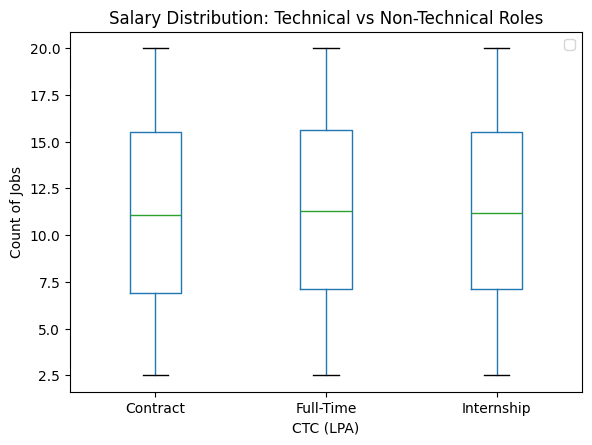

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"https://raw.githubusercontent.com/aysh01/MNC-Hiring-Trends-Project/refs/heads/main/IT_MNC_Hiring_2025_cleaned.csv")

# Grouped salary analysis
salary_stats = df.groupby("Hiring_Type")["CTC(LPA)"].describe()
print(salary_stats)

# Visualization
# plt.hist(
#     [df[df["Hiring_Type"]=="Technical"]["CTC(LPA)"], df[df["Hiring_Type"]=="Non-Technical"]["CTC(LPA)"]],
#     label=["Technical", "Non-Technical"],
#     bins=30,
#     alpha=0.7
# )
df.boxplot(column="CTC(LPA)", by="Hiring_Type", grid=False)

plt.title("Salary Distribution: Technical vs Non-Technical Roles")
plt.suptitle("")
plt.xlabel("CTC (LPA)")
plt.ylabel("Count of Jobs")
plt.legend()
plt.show()

<hr>